<a href="https://colab.research.google.com/github/leman-cap13/DL_projects/blob/main/CNN_Architectures.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Implementing a ResNet-34 CNN Using PyTorch

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from functools import partial

class ResidualUnit(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        DefaultConv2d = partial(
            nn.Conv2d, kernel_size=3, stride=1, padding=1)

        self.main_layers = nn.Sequential(
            DefaultConv2d(in_channels, out_channels, stride=stride),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            DefaultConv2d(out_channels, out_channels),
            nn.BatchNorm2d(out_channels),
        )
        if stride > 1: # shape matching  ( I + 2P - K / S) + 1  conv 1x1
            self.skip_connection = nn.Sequential(
                DefaultConv2d(in_channels, out_channels, kernel_size=1,
                              stride=stride, padding=0),
                nn.BatchNorm2d(out_channels),
            )
        else:
            self.skip_connection = nn.Identity()  # input tensor

    def forward(self, inputs):
        return F.relu(self.main_layers(inputs) + self.skip_connection(inputs))

In [ ]:
class ResNet34(nn.Module):
    def __init__(self):
        super().__init__()
        layers = [
            nn.Conv2d(in_channels=3, out_channels=64, kernel_size=7, stride=2,
                      padding=3, bias=False),
            nn.BatchNorm2d(num_features=64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1), # padding = "same", "valid"=0, "tuple", "int"
        ]
        prev_filters = 64
        for filters in [64] * 3 + [128] * 4 + [256] * 6 + [512] * 3:
            stride = 1 if filters == prev_filters else 2
            layers.append(ResidualUnit(prev_filters, filters, stride=stride))
            prev_filters = filters
        layers += [
            nn.AdaptiveAvgPool2d(output_size=1), # global pooling
            nn.Flatten(),
            nn.LazyLinear(10), # output size=10 ... no input size
        ]
        self.resnet = nn.Sequential(*layers)

    def forward(self, inputs):
        return self.resnet(inputs)

#Using TorchVision’s Pretrained Models

In [ ]:
import torchvision
import torch

device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

weights= torchvision.models.ConvNeXt_Base_Weights.IMAGENET1K_V1

model=torchvision.models.convnext_base(weights=weights).to(device)

Downloading: "https://download.pytorch.org/models/convnext_base-6075fbad.pth" to /root/.cache/torch/hub/checkpoints/convnext_base-6075fbad.pth


100%|██████████| 338M/338M [00:01<00:00, 196MB/s]


In [ ]:
from sklearn.datasets import load_sample_images
import numpy as np
sample_images =np.stack(load_sample_images()["images"])
sample_images =torch.tensor(sample_images, dtype=torch.float32) / 255  # B, H, W, C

In [ ]:
sample_images_permuted=sample_images.permute(0,3,1,2) # B, C, H, W

In [ ]:
transforms = weights.transforms()
preprocessed_images = transforms(sample_images_permuted)

In [ ]:
model.eval()
with torch.no_grad():
    y_logits = model(preprocessed_images.to(device))

In [ ]:
y_pred = torch.argmax(y_logits, dim=1)
y_pred

tensor([698, 985], device='cuda:0')

In [ ]:
class_names = weights.meta["categories"]
[class_names[class_id] for class_id in y_pred]

['palace', 'daisy']

In [ ]:
y_top3_logits, y_top3_class_ids = y_logits.topk(k=3, dim=1)
[[class_names[class_id] for class_id in top3] for top3 in y_top3_class_ids]

[['palace', 'monastery', 'lakeside'], ['daisy', 'pot', 'ant']]

In [ ]:
y_top3_logits.softmax(dim=1)


tensor([[0.8618, 0.1185, 0.0197],
        [0.8106, 0.0964, 0.0930]], device='cuda:0')

#Pretrained Models for Transfer Learning

In [ ]:
from functools import partial

In [ ]:
DefaultFlowers102 = partial(
    torchvision.datasets.Flowers102,
    root="datasets",
    transform=weights.transforms(),
    download=True)

train_set = DefaultFlowers102(split="train")
valid_set = DefaultFlowers102(split="val")
test_set = DefaultFlowers102(split="test")

100%|██████████| 345M/345M [00:13<00:00, 25.7MB/s]
100%|██████████| 502/502 [00:00<00:00, 1.22MB/s]
100%|██████████| 15.0k/15.0k [00:00<00:00, 28.1MB/s]


In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_set,
    batch_size=32,
    shuffle=True)


valid_loader = DataLoader(
    valid_set,
    batch_size=32)


test_loader = DataLoader(
    test_set,
    batch_size=32)

In [ ]:
[name for name, child in model.named_children()]

['features', 'avgpool', 'classifier']

In [ ]:
model.avgpool

AdaptiveAvgPool2d(output_size=1)

In [ ]:
model.classifier

Sequential(
  (0): LayerNorm2d((1024,), eps=1e-06, elementwise_affine=True)
  (1): Flatten(start_dim=1, end_dim=-1)
  (2): Linear(in_features=1024, out_features=1000, bias=True)
)

In [ ]:
model.features

Sequential(
  (0): Conv2dNormActivation(
    (0): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
    (1): LayerNorm2d((128,), eps=1e-06, elementwise_affine=True)
  )
  (1): Sequential(
    (0): CNBlock(
      (block): Sequential(
        (0): Conv2d(128, 128, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=128)
        (1): Permute()
        (2): LayerNorm((128,), eps=1e-06, elementwise_affine=True)
        (3): Linear(in_features=128, out_features=512, bias=True)
        (4): GELU(approximate='none')
        (5): Linear(in_features=512, out_features=128, bias=True)
        (6): Permute()
      )
      (stochastic_depth): StochasticDepth(p=0.0, mode=row)
    )
    (1): CNBlock(
      (block): Sequential(
        (0): Conv2d(128, 128, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=128)
        (1): Permute()
        (2): LayerNorm((128,), eps=1e-06, elementwise_affine=True)
        (3): Linear(in_features=128, out_features=512, bias=True)
        (4): GELU(approx

In [ ]:
import torch.nn as nn

In [ ]:
n_classes = 102  # len(class_names) == 102
model.classifier[2] = nn.Linear(1024, n_classes).to(device)

In [ ]:
for param in model.parameters():
    param.requires_grad = False

for param in model.classifier.parameters():
    param.requires_grad = True

In [ ]:
import torchvision.transforms.v2 as T

transforms = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=30),
    T.RandomResizedCrop(size=(224, 224), scale=(0.8, 1.0)),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [ ]:
import torch.optim as optim

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.classifier.parameters(), lr=1e-3, weight_decay=1e-4)

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    running_correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)


        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        running_correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    return epoch_loss, epoch_acc


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        running_correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    return epoch_loss, epoch_acc




In [ ]:
epochs_stage1 = 5

for epoch in range(epochs_stage1):

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)

    val_loss, val_acc = evaluate(model, valid_loader, criterion, device)

    print(
        f"Epoch {epoch+1}/{epochs_stage1} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
    )

Epoch 1/5 | train_loss=4.2857 train_acc=0.1343 | val_loss=3.5061 val_acc=0.5745
Epoch 2/5 | train_loss=3.0113 train_acc=0.6833 | val_loss=2.5280 val_acc=0.7520
Epoch 3/5 | train_loss=2.0653 train_acc=0.8529 | val_loss=1.8103 val_acc=0.8206
Epoch 4/5 | train_loss=1.3891 train_acc=0.9127 | val_loss=1.3534 val_acc=0.8578
Epoch 5/5 | train_loss=0.9304 train_acc=0.9510 | val_loss=1.0702 val_acc=0.8725


In [ ]:
for param in model.parameters():
    param.requires_grad = True

optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

epochs_stage2 = 5

for epoch in range(epochs_stage2):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, valid_loader, criterion, device)

    print(
        f"[FT] Epoch {epoch+1}/{epochs_stage2} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
    )



[FT] Epoch 1/5 | train_loss=0.2890 train_acc=0.9755 | val_loss=0.3475 val_acc=0.9441
[FT] Epoch 2/5 | train_loss=0.0594 train_acc=0.9990 | val_loss=0.2714 val_acc=0.9510
[FT] Epoch 3/5 | train_loss=0.0282 train_acc=1.0000 | val_loss=0.2383 val_acc=0.9598
[FT] Epoch 4/5 | train_loss=0.0165 train_acc=1.0000 | val_loss=0.2178 val_acc=0.9588
[FT] Epoch 5/5 | train_loss=0.0128 train_acc=1.0000 | val_loss=0.2080 val_acc=0.9588


In [ ]:
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"Test loss: {test_loss:.4f} | Test acc: {test_acc:.4f}")

Test loss: 0.2472 | Test acc: 0.9515


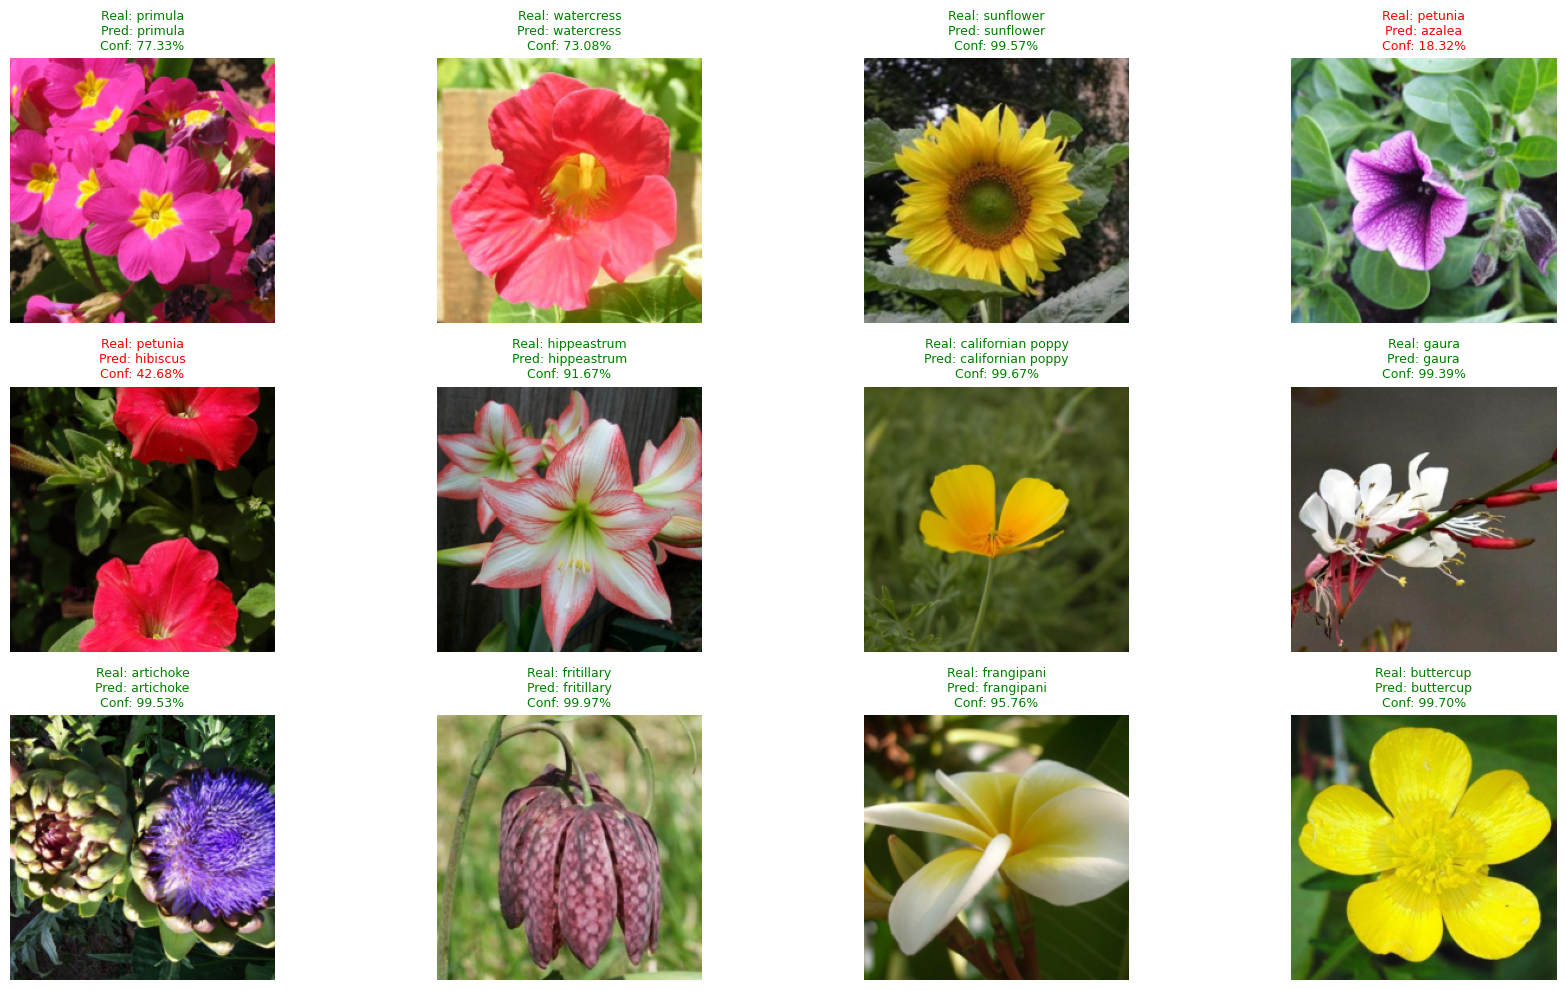

In [ ]:
import json
import urllib.request
import random
import matplotlib.pyplot as plt


url = "https://raw.githubusercontent.com/udacity/aipnd-project/master/cat_to_name.json"
urllib.request.urlretrieve(url, "cat_to_name.json")

with open("cat_to_name.json", "r") as f:
    cat_to_name = json.load(f)

class_names = [cat_to_name[str(i)] for i in range(1, 103)]


mean = torch.tensor([0.485, 0.456, 0.406])
std = torch.tensor([0.229, 0.224, 0.225])

indices = random.sample(range(len(test_set)), 12)

model.eval()
plt.figure(figsize=(18, 10))

for i, idx in enumerate(indices):
    image, true_label = test_set[idx]

    input_image = image.unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(input_image)
        probs = torch.softmax(logits, dim=1)
        pred_prob, pred_label = probs.max(dim=1)

    pred_label = pred_label.item()
    pred_prob = pred_prob.item()

    img = image.cpu() * std[:, None, None] + mean[:, None, None]
    img = img.clamp(0, 1).permute(1, 2, 0)

    plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.axis("off")

    color = "green" if pred_label == true_label else "red"

    plt.title(
        f"Real: {class_names[true_label]}\n"
        f"Pred: {class_names[pred_label]}\n"
        f"Conf: {pred_prob:.2%}",
        color=color,
        fontsize=9
    )

plt.tight_layout()
plt.show()